<a href="https://colab.research.google.com/github/shrey-sood/embedded/blob/main/Embedded_Systems_Gas_Fault_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IoT-Based Gas Sensor Fault Detection Using Advanced Time-Series Models

### Embedded Systems Project

**Models Compared:**
- ANN–HMM
- LSTM
- GRU
- TCN
- Transformer

**Evaluation Metrics:**
- Accuracy
- Precision
- Fault Detection Delay
- Inference Time
- Response Time
- Power Consumption
- Battery Life

## 1. Objective

The objective of this project is to develop and compare advanced time-series models
for detecting faults in gas sensor data.

The existing ANN–HMM approach will be used as the baseline and compared with:
LSTM, GRU, TCN and Transformer models.

The models will be evaluated based on detection performance and embedded-system
constraints such as inference time, response time and power consumption.

In [3]:

# STEP 1: IMPORT REQUIRED LIBRARIES


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Check Python and important package versions

import sys
import sklearn
import tensorflow as tf

print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Scikit-learn version: 1.6.1
TensorFlow version: 2.20.0


In [5]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [7]:
!pip -q install ucimlrepo

In [8]:
from ucimlrepo import fetch_ucirepo

# Load UCI Gas Sensor Array Drift Dataset
gas_dataset = fetch_ucirepo(id=270)

X = gas_dataset.data.features
y = gas_dataset.data.targets

print("Dataset loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 rows of y:")
display(y.head())

Dataset loaded successfully!
X shape: (13910, 128)
y shape: (13910, 1)

First 5 rows of X:


,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature119,Feature120,Feature121,Feature122,Feature123,Feature124,Feature125,Feature126,Feature127,Feature128
1;10.000000,2:1.868245,3:2.371604,4:2.803678,5:7.512213,6:-2.739388,7:-3.344671,8:-4.847512,9:15326.691400,10:1.768526,11:2.269085,...,120:-3.037772,121:3037.039000,122:3.972203,123:0.527291,124:0.728443,125:1.445783,126:-0.545079,127:-0.902241,128:-2.654529,NaN
1;20.000000,2:2.532401,3:5.411209,4:6.509906,5:7.658469,6:-4.722217,7:-5.817651,8:-7.518333,9:23855.781200,10:2.164706,11:4.901063,...,120:-1.994993,121:4176.445300,122:4.281373,123:0.980205,124:1.628050,125:1.951172,126:-0.889333,127:-1.323505,128:-1.749225,NaN
1;30.000000,2:3.454189,3:8.198175,4:10.508439,5:11.611003,6:-7.668313,7:-9.478675,8:-12.230939,9:37562.300800,10:2.840403,11:7.386357,...,120:-2.867291,121:5914.668500,122:5.396827,123:1.403973,124:2.476956,125:3.039841,126:-1.334558,127:-1.993659,128:-2.348370,NaN
1;40.000000,2:3.451192,3:12.113940,4:16.266853,5:39.910056,6:-7.849409,7:-9.689894,8:-11.921704,9:38379.066400,10:2.851173,11:10.840889,...,120:-3.058086,121:6147.474400,122:5.501071,123:1.981933,124:3.569823,125:4.049197,126:-1.432205,127:-2.146158,128:-2.488957,NaN
1;50.000000,2:4.194839,3:11.455096,4:15.715298,5:17.654915,6:-11.083364,7:-13.580692,8:-16.407848,9:51975.589900,10:3.480866,11:10.409176,...,120:-4.181920,121:8158.644900,122:7.174334,123:1.993808,124:3.829303,125:4.402448,126:-1.930107,127:-2.931265,128:-4.088756,NaN



First 5 rows of y:


,class
1;10.000000,1:15596.162100
1;20.000000,1:26402.070400
1;30.000000,1:42103.582000
1;40.000000,1:42825.988300
1;50.000000,1:58151.175700


In [10]:
# ============================================================
# CLEAN THE UCI GAS SENSOR DATASET
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Clean the 128 sensor features
# ------------------------------------------------------------

X_clean = X.copy()

for col in X_clean.columns:
    X_clean[col] = (
        X_clean[col]
        .astype(str)
        .str.split(':')
        .str[-1]
        .astype(float)
    )

X_clean.columns = [f'feature_{i}' for i in range(1, 129)]


# ------------------------------------------------------------
# 2. Extract gas class and concentration from the index
# ------------------------------------------------------------

index_strings = pd.Series(y.index.astype(str))

index_parts = index_strings.str.split(';', expand=True)

gas_class = index_parts[0].astype(int)
concentration = index_parts[1].astype(float)


# ------------------------------------------------------------
# 3. Create clean target dataframe
# ------------------------------------------------------------

y_clean = pd.DataFrame({
    'gas_class': gas_class,
    'concentration': concentration
})


# ------------------------------------------------------------
# 4. Reset indexes so X and y line up properly
# ------------------------------------------------------------

X_clean = X_clean.reset_index(drop=True)
y_clean = y_clean.reset_index(drop=True)


# ------------------------------------------------------------
# 5. Display everything
# ------------------------------------------------------------

print("========================================")
print("DATASET CLEANING COMPLETE")
print("========================================")

print("\nX shape:", X_clean.shape)
print("y shape:", y_clean.shape)

print("\nFirst 5 sensor records:")
display(X_clean.head())

print("\nFirst 5 target records:")
display(y_clean.head())

print("\nGas class distribution:")
print(y_clean['gas_class'].value_counts().sort_index())

print("\nConcentration range:")
print(
    "Minimum:", y_clean['concentration'].min(),
    "| Maximum:", y_clean['concentration'].max()
)

print("\nMissing values in X:", X_clean.isnull().sum().sum())
print("Missing values in y:", y_clean.isnull().sum().sum())

DATASET CLEANING COMPLETE

X shape: (13910, 128)
y shape: (13910, 2)

First 5 sensor records:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,1.768526,2.269085,...,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,NaN
1,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,2.164706,4.901063,...,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225,NaN
2,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,2.840403,7.386357,...,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370,NaN
3,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,-11.921704,38379.0664,2.851173,10.840889,...,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957,NaN
4,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,51975.5899,3.480866,10.409176,...,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756,NaN



First 5 target records:


,gas_class,concentration
0,1,10.0
1,1,20.0
2,1,30.0
3,1,40.0
4,1,50.0



Gas class distribution:
gas_class
1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64

Concentration range:
Minimum: 1.0 | Maximum: 1000.0

Missing values in X: 13910
Missing values in y: 0


In [11]:
# ============================================================
# DATASET EXPLORATION
# ============================================================

print("Gas classes:")
print(y_clean['gas_class'].value_counts().sort_index())

print("\nGas class + concentration combinations:")
display(
    y_clean.groupby(['gas_class', 'concentration'])
           .size()
           .reset_index(name='number_of_samples')
)

print("\nFeature statistics:")
display(X_clean.describe().T.head(20))

Gas classes:
gas_class
1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64

Gas class + concentration combinations:


,gas_class,concentration,number_of_samples
0,1,2.5,41
1,1,5.0,1
2,1,10.0,289
3,1,20.0,41
4,1,25.0,49
...,...,...,...
228,6,160.0,4
229,6,180.0,1
230,6,190.0,1
231,6,220.0,2



Feature statistics:


,count,mean,std,min,25%,50%,75%,max
feature_1,13910.0,6.638156,13.486391,0.088287,2.284843,3.871227,8.400619,1339.879283
feature_2,13910.0,12.936688,17.610061,0.000100,1.633350,4.977123,17.189166,167.079751
feature_3,13910.0,18.743953,24.899450,0.000100,2.386836,7.250892,26.411109,226.619457
feature_4,13910.0,26.890695,38.107685,0.000100,4.967988,11.680725,34.843226,993.605306
feature_5,13910.0,-9.158655,12.729206,-131.332873,-11.587169,-3.338700,-1.126897,-0.006941
feature_6,13910.0,-14.402383,21.304606,-227.627758,-17.292559,-4.956917,-1.670327,22.201589
feature_7,13910.0,-59.927598,131.017675,-1664.735576,-48.492764,-14.040088,-5.212213,115.273147
feature_8,13910.0,57340.104585,64045.265134,-16119.460900,13287.301875,37764.263200,70300.782575,502202.812500
feature_9,13910.0,6.648033,15.585780,0.185164,2.776693,4.734586,8.608522,1672.363221
feature_10,13910.0,15.538389,16.557172,0.002252,3.700962,9.968119,20.383726,131.449632


In [12]:
# ============================================================
# CHECK DATA ORDER AND GROUP TRANSITIONS
# ============================================================

# Combine target information with row number
data_info = y_clean.copy()
data_info['row'] = range(len(data_info))

# Show the first 30 observations
print("First 30 observations:")
display(data_info.head(30))

# Find where gas class or concentration changes
data_info['group'] = (
    data_info['gas_class'].astype(str)
    + "_"
    + data_info['concentration'].astype(str)
)

data_info['group_change'] = (
    data_info['group'] != data_info['group'].shift()
)

group_starts = data_info[data_info['group_change']]

print("\nNumber of contiguous groups:", len(group_starts))

print("\nFirst 20 group transitions:")
display(
    group_starts[
        ['row', 'gas_class', 'concentration', 'group']
    ].head(20)
)

print("\nLast 20 group transitions:")
display(
    group_starts[
        ['row', 'gas_class', 'concentration', 'group']
    ].tail(20)
)

First 30 observations:


,gas_class,concentration,row
0,1,10.0,0
1,1,20.0,1
2,1,30.0,2
3,1,40.0,3
4,1,50.0,4
5,1,75.0,5
6,1,100.0,6
7,1,125.0,7
8,1,150.0,8
9,1,175.0,9



Number of contiguous groups: 8982

First 20 group transitions:


,row,gas_class,concentration,group
0,0,1,10.0,1_10.0
1,1,1,20.0,1_20.0
2,2,1,30.0,1_30.0
3,3,1,40.0,1_40.0
4,4,1,50.0,1_50.0
5,5,1,75.0,1_75.0
6,6,1,100.0,1_100.0
7,7,1,125.0,1_125.0
8,8,1,150.0,1_150.0
9,9,1,175.0,1_175.0



Last 20 group transitions:


,row,gas_class,concentration,group
13890,13890,4,150.0,4_150.0
13891,13891,5,1000.0,5_1000.0
13892,13892,4,50.0,4_50.0
13893,13893,5,200.0,5_200.0
13894,13894,4,100.0,4_100.0
13895,13895,5,800.0,5_800.0
13896,13896,4,200.0,4_200.0
13897,13897,5,400.0,5_400.0
13898,13898,4,50.0,4_50.0
13899,13899,5,200.0,5_200.0


## 2. Raw Gas Sensor Time-Series Dataset

For the time-series fault detection experiments, the UCI Gas Sensor Array
Under Flow Modulation dataset is used.

The dataset contains 58 experiments recorded using 16 chemical sensors.
Each sensor provides 7,500 time-series measurements sampled at 25 Hz over
a 5-minute experiment.

The raw sensor signals will be used to construct temporal windows and
evaluate ANN-HMM, LSTM, GRU, TCN and Transformer models.

In [13]:
# ============================================================
# DOWNLOAD RAW TIME-SERIES DATA
# ============================================================

import requests
import gzip
import shutil
import os

url = "https://archive.ics.uci.edu/static/public/308/gas+sensor+array+under+flow+modulation.zip"

response = requests.get(url)

print("Download status:", response.status_code)
print("Downloaded:", len(response.content), "bytes")

with open("/content/gas_sensor_dataset.zip", "wb") as f:
    f.write(response.content)

print("Dataset downloaded successfully!")

Download status: 200
Downloaded: 4790478 bytes
Dataset downloaded successfully!


In [15]:
# ============================================================
# EXTRACT DATASET
# ============================================================

import zipfile
import os

zip_path = "/content/gas_sensor_dataset.zip"
extract_path = "/content/gas_sensor_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Extracted files:
/content/gas_sensor_dataset/features.csv
/content/gas_sensor_dataset/rawdata.csv.gz


In [16]:
# ============================================================
# DOWNLOAD RAW TIME-SERIES FILE
# ============================================================

import requests
import os

raw_url = "https://archive.ics.uci.edu/static/public/308/rawdata.csv.gz"

response = requests.get(raw_url)

print("Download status:", response.status_code)
print("Downloaded:", len(response.content), "bytes")

with open("/content/rawdata.csv.gz", "wb") as f:
    f.write(response.content)

print("Raw time-series file saved!")

Download status: 404
Downloaded: 9 bytes
Raw time-series file saved!


In [17]:
# ============================================================
# VERIFY RAW FILE
# ============================================================

import os

file_path = "/content/rawdata.csv.gz"

print("File exists:", os.path.exists(file_path))

if os.path.exists(file_path):
    print("File size:", round(os.path.getsize(file_path) / (1024 * 1024), 2), "MB")

File exists: True
File size: 0.0 MB


In [18]:
# Show EVERYTHING inside the dataset folder

import os

for root, dirs, files in os.walk("/content/gas_sensor_dataset"):
    print(f"\n📁 {root}")
    for file in files:
        path = os.path.join(root, file)
        size = os.path.getsize(path) / 1024
        print(f"   {file}  ({size:.1f} KB)")


📁 /content/gas_sensor_dataset
   features.csv  (201.5 KB)
   rawdata.csv.gz  (4648.4 KB)


In [19]:
# ============================================================
# LOAD RAW GAS SENSOR TIME-SERIES DATA
# ============================================================

import pandas as pd
import gzip

raw_path = "/content/gas_sensor_dataset/rawdata.csv.gz"

raw_data = pd.read_csv(
    raw_path,
    compression="gzip"
)

print("Raw dataset loaded!")
print("Shape:", raw_data.shape)

print("\nColumns:")
print(raw_data.columns.tolist())

print("\nFirst 5 rows:")
display(raw_data.head())

Raw dataset loaded!
Shape: (928, 7509)

Columns:
['sensor', 'sample', 'exp', 'batch', 'ace_conc', 'eth_conc', 'gas', 'lab', 'col', 'dR_t1', 'dR_t2', 'dR_t3', 'dR_t4', 'dR_t5', 'dR_t6', 'dR_t7', 'dR_t8', 'dR_t9', 'dR_t10', 'dR_t11', 'dR_t12', 'dR_t13', 'dR_t14', 'dR_t15', 'dR_t16', 'dR_t17', 'dR_t18', 'dR_t19', 'dR_t20', 'dR_t21', 'dR_t22', 'dR_t23', 'dR_t24', 'dR_t25', 'dR_t26', 'dR_t27', 'dR_t28', 'dR_t29', 'dR_t30', 'dR_t31', 'dR_t32', 'dR_t33', 'dR_t34', 'dR_t35', 'dR_t36', 'dR_t37', 'dR_t38', 'dR_t39', 'dR_t40', 'dR_t41', 'dR_t42', 'dR_t43', 'dR_t44', 'dR_t45', 'dR_t46', 'dR_t47', 'dR_t48', 'dR_t49', 'dR_t50', 'dR_t51', 'dR_t52', 'dR_t53', 'dR_t54', 'dR_t55', 'dR_t56', 'dR_t57', 'dR_t58', 'dR_t59', 'dR_t60', 'dR_t61', 'dR_t62', 'dR_t63', 'dR_t64', 'dR_t65', 'dR_t66', 'dR_t67', 'dR_t68', 'dR_t69', 'dR_t70', 'dR_t71', 'dR_t72', 'dR_t73', 'dR_t74', 'dR_t75', 'dR_t76', 'dR_t77', 'dR_t78', 'dR_t79', 'dR_t80', 'dR_t81', 'dR_t82', 'dR_t83', 'dR_t84', 'dR_t85', 'dR_t86', 'dR_t87', 'dR_t88'

,sensor,sample,exp,batch,ace_conc,eth_conc,gas,lab,col,dR_t1,...,dR_t7491,dR_t7492,dR_t7493,dR_t7494,dR_t7495,dR_t7496,dR_t7497,dR_t7498,dR_t7499,dR_t7500
0,1,1,100,day-1-morning,0.0,0.0,air,air,252525,0,...,-0.00402,-0.00402,-0.00402,-0.00416,-0.00416,-0.00416,-0.00416,-0.00389,-0.00389,-0.00389
1,2,1,100,day-1-morning,0.0,0.0,air,air,252525,0,...,-0.00434,-0.00434,-0.00434,-0.00422,-0.00422,-0.00422,-0.00422,-0.00392,-0.00392,-0.00392
2,3,1,100,day-1-morning,0.0,0.0,air,air,252525,0,...,-0.00027,-0.00027,-0.00027,-0.00027,-0.00027,-0.00027,-0.00027,-0.00013,-0.00013,-0.00013
3,4,1,100,day-1-morning,0.0,0.0,air,air,252525,0,...,-0.00131,-0.00131,-0.00131,-0.00137,-0.00137,-0.00137,-0.00137,-0.00131,-0.00131,-0.00131
4,5,1,100,day-1-morning,0.0,0.0,air,air,252525,0,...,-0.00362,-0.00362,-0.00362,-0.00326,-0.00326,-0.00326,-0.00326,-0.00355,-0.00355,-0.00355


In [20]:
# ============================================================
# UNDERSTAND THE RAW TIME-SERIES EXPERIMENTS
# ============================================================

# Identify the 7,500 time-series columns
time_columns = [col for col in raw_data.columns if col.startswith('dR_t')]

print("Number of time points:", len(time_columns))
print("First time point:", time_columns[0])
print("Last time point:", time_columns[-1])

print("\nNumber of unique experiments:", raw_data['exp'].nunique())
print("Number of sensors:", raw_data['sensor'].nunique())
print("Sensors:", sorted(raw_data['sensor'].unique()))

print("\nGas distribution:")
print(raw_data['gas'].value_counts())

print("\nExperiment summary:")
experiment_summary = (
    raw_data.groupby('exp')
    .agg(
        sensors=('sensor', 'nunique'),
        gas=('gas', 'first'),
        ace_conc=('ace_conc', 'first'),
        eth_conc=('eth_conc', 'first'),
        batch=('batch', 'first')
    )
    .reset_index()
)

display(experiment_summary)

print("\nDataset dimensions:")
print("Experiments :", raw_data['exp'].nunique())
print("Sensors     :", raw_data['sensor'].nunique())
print("Time points :", len(time_columns))

Number of time points: 7500
First time point: dR_t1
Last time point: dR_t7500

Number of unique experiments: 58
Number of sensors: 16
Sensors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

Gas distribution:
gas
mixture    320
ethanol    240
acetone    240
air        128
Name: count, dtype: int64

Experiment summary:


,exp,sensors,gas,ace_conc,eth_conc,batch
0,100,16,air,0.0,0.0,day-1-morning
1,101,16,ethanol,0.0,0.1,day-1-morning
2,102,16,ethanol,0.0,1.0,day-1-morning
3,103,16,acetone,0.3,0.0,day-1-morning
4,104,16,mixture,0.3,0.1,day-1-morning
5,105,16,ethanol,0.0,0.3,day-1-morning
6,106,16,acetone,1.0,0.0,day-1-morning
7,107,16,mixture,0.1,0.3,day-1-morning
8,108,16,acetone,0.1,0.0,day-1-morning
9,112,16,acetone,0.3,0.0,day-1-morning



Dataset dimensions:
Experiments : 58
Sensors     : 16
Time points : 7500


In [21]:
# ============================================================
# RESHAPE RAW DATA INTO TIME-SERIES FORMAT
# ============================================================

# Get the 7,500 time-series columns
time_columns = [col for col in raw_data.columns if col.startswith('dR_t')]

# Sort them numerically to guarantee correct time order
time_columns = sorted(
    time_columns,
    key=lambda x: int(x.replace('dR_t', ''))
)

print("Time columns:", len(time_columns))

# ------------------------------------------------------------
# Verify every experiment has exactly 16 sensors
# ------------------------------------------------------------

sensor_counts = raw_data.groupby('exp')['sensor'].nunique()

print("\nSensor count per experiment:")
print(sensor_counts.value_counts())

if (sensor_counts == 16).all():
    print("✓ Every experiment contains 16 sensors")
else:
    print("⚠ Some experiments do not contain 16 sensors")


# ------------------------------------------------------------
# Create the 3D time-series array
# ------------------------------------------------------------

experiments = sorted(raw_data['exp'].unique())

X_timeseries = np.zeros(
    (len(experiments), len(time_columns), 16)
)

experiment_metadata = []

for i, exp_id in enumerate(experiments):

    exp_data = raw_data[raw_data['exp'] == exp_id].copy()

    # Sort sensors 1 → 16
    exp_data = exp_data.sort_values('sensor')

    # Extract sensor time-series
    sensor_values = exp_data[time_columns].values

    # Convert:
    # (16 sensors, 7500 time points)
    # →
    # (7500 time points, 16 sensors)

    X_timeseries[i] = sensor_values.T

    # Save experiment-level metadata
    first_row = exp_data.iloc[0]

    experiment_metadata.append({
        'exp': exp_id,
        'gas': first_row['gas'],
        'ace_conc': first_row['ace_conc'],
        'eth_conc': first_row['eth_conc'],
        'batch': first_row['batch']
    })


experiment_metadata = pd.DataFrame(experiment_metadata)


# ------------------------------------------------------------
# Display final structure
# ------------------------------------------------------------

print("\n========================================")
print("TIME-SERIES DATA READY")
print("========================================")

print("X_timeseries shape:", X_timeseries.shape)

print("\nMeaning:")
print("Experiments :", X_timeseries.shape[0])
print("Time steps  :", X_timeseries.shape[1])
print("Sensors     :", X_timeseries.shape[2])

print("\nExperiment metadata:")
display(experiment_metadata)

Time columns: 7500

Sensor count per experiment:
sensor
16    58
Name: count, dtype: int64
✓ Every experiment contains 16 sensors

TIME-SERIES DATA READY
X_timeseries shape: (58, 7500, 16)

Meaning:
Experiments : 58
Time steps  : 7500
Sensors     : 16

Experiment metadata:


,exp,gas,ace_conc,eth_conc,batch
0,100,air,0.0,0.0,day-1-morning
1,101,ethanol,0.0,0.1,day-1-morning
2,102,ethanol,0.0,1.0,day-1-morning
3,103,acetone,0.3,0.0,day-1-morning
4,104,mixture,0.3,0.1,day-1-morning
5,105,ethanol,0.0,0.3,day-1-morning
6,106,acetone,1.0,0.0,day-1-morning
7,107,mixture,0.1,0.3,day-1-morning
8,108,acetone,0.1,0.0,day-1-morning
9,112,acetone,0.3,0.0,day-1-morning


In [22]:
# ============================================================
# INSPECT SENSOR RANGES
# ============================================================

# Reshape temporarily:
# (experiments, time, sensors)
# -> (all measurements, sensors)

X_flat = X_timeseries.reshape(-1, 16)

sensor_stats = pd.DataFrame({
    'sensor': [f'Sensor {i}' for i in range(1, 17)],
    'minimum': X_flat.min(axis=0),
    'maximum': X_flat.max(axis=0),
    'mean': X_flat.mean(axis=0),
    'std': X_flat.std(axis=0)
})

display(sensor_stats)

,sensor,minimum,maximum,mean,std
0,Sensor 1,-0.01643,0.78780,0.179618,0.175529
1,Sensor 2,-0.01393,0.74572,0.181149,0.172422
2,Sensor 3,-0.09670,6.09739,0.981135,1.177342
3,Sensor 4,-0.06512,2.42631,0.583073,0.567362
4,Sensor 5,-0.01759,0.94271,0.213027,0.207978
5,Sensor 6,-0.01078,0.47646,0.102176,0.095004
6,Sensor 7,-0.01479,0.74827,0.180758,0.165185
7,Sensor 8,-0.04898,1.79803,0.451351,0.428205
8,Sensor 9,-0.09656,1.63553,0.389182,0.388151
9,Sensor 10,-0.09740,2.74882,0.600219,0.602619


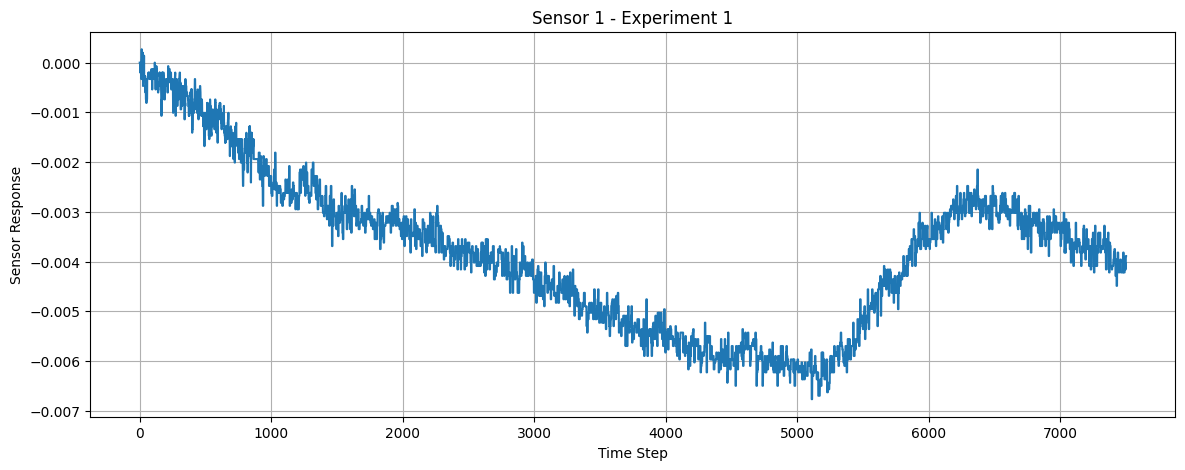

In [23]:
# ============================================================
# VISUALIZE RAW SENSOR TIME SERIES
# ============================================================

plt.figure(figsize=(14, 5))

# Experiment 1, Sensor 1
plt.plot(X_timeseries[0, :, 0])

plt.title('Sensor 1 - Experiment 1')
plt.xlabel('Time Step')
plt.ylabel('Sensor Response')
plt.grid(True)

plt.show()

In [24]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# ------------------------------------------------------------
# 1. Get experiment indices
# ------------------------------------------------------------

experiment_indices = np.arange(X_timeseries.shape[0])

# 70% training, 30% temporary
train_idx, temp_idx = train_test_split(
    experiment_indices,
    test_size=0.30,
    random_state=42
)

# Split remaining 30% equally:
# 15% validation, 15% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42
)

print("Training experiments  :", len(train_idx))
print("Validation experiments:", len(val_idx))
print("Testing experiments   :", len(test_idx))


# ------------------------------------------------------------
# 2. Separate the datasets
# ------------------------------------------------------------

X_train_raw = X_timeseries[train_idx]
X_val_raw   = X_timeseries[val_idx]
X_test_raw  = X_timeseries[test_idx]


# ------------------------------------------------------------
# 3. Normalize sensor values
# ------------------------------------------------------------
# IMPORTANT:
# The scaler is fitted ONLY on training data.

scaler = StandardScaler()

# Flatten training data temporarily
train_flat = X_train_raw.reshape(-1, 16)

scaler.fit(train_flat)

# Apply the same scaler to all datasets
X_train = scaler.transform(
    X_train_raw.reshape(-1, 16)
).reshape(X_train_raw.shape)

X_val = scaler.transform(
    X_val_raw.reshape(-1, 16)
).reshape(X_val_raw.shape)

X_test = scaler.transform(
    X_test_raw.reshape(-1, 16)
).reshape(X_test_raw.shape)


# ------------------------------------------------------------
# 4. Verify normalization
# ------------------------------------------------------------

print("\n========================================")
print("NORMALIZATION COMPLETE")
print("========================================")

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTraining mean per sensor:")
print(np.round(X_train.reshape(-1, 16).mean(axis=0), 3))

print("\nTraining std per sensor:")
print(np.round(X_train.reshape(-1, 16).std(axis=0), 3))

Training experiments  : 40
Validation experiments: 9
Testing experiments   : 9

NORMALIZATION COMPLETE

Train shape: (40, 7500, 16)
Validation shape: (9, 7500, 16)
Test shape: (9, 7500, 16)

Training mean per sensor:
[ 0.  0.  0. -0. -0.  0.  0.  0. -0. -0. -0. -0. -0.  0.  0. -0.]

Training std per sensor:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [25]:
# ============================================================
# FAULT INJECTION FUNCTIONS
# ============================================================

import numpy as np


def inject_constant_fault(data, start=3000, duration=1000, sensor=0):
    """
    Constant fault:
    Sensor gets stuck at its value at the beginning of the fault.
    """

    faulty = data.copy()

    constant_value = faulty[start, sensor]

    faulty[start:start + duration, sensor] = constant_value

    return faulty


def inject_noise_fault(data, start=3000, duration=1000,
                       sensor=0, noise_level=2.0):
    """
    Noise fault:
    Abnormal Gaussian noise is added to one sensor.
    """

    faulty = data.copy()

    noise = np.random.normal(
        loc=0,
        scale=noise_level,
        size=duration
    )

    faulty[start:start + duration, sensor] += noise

    return faulty


def inject_short_fault(data, start=3000, duration=100,
                       sensor=0):
    """
    Short/intermittent fault:
    Sensor temporarily experiences a large deviation.
    """

    faulty = data.copy()

    faulty[start:start + duration, sensor] += 5.0

    return faulty


print("Fault injection functions created successfully!")

Fault injection functions created successfully!


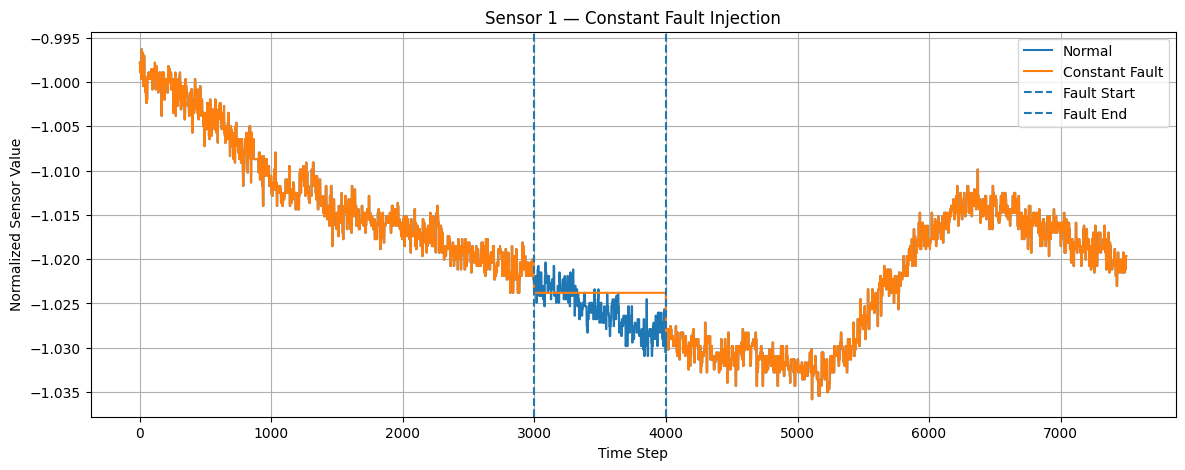

In [26]:
# ============================================================
# TEST FAULT INJECTION
# ============================================================

# Use the first test experiment
normal_signal = X_test[0].copy()

# Create three faulty versions
constant_signal = inject_constant_fault(
    normal_signal,
    start=3000,
    duration=1000,
    sensor=0
)

noise_signal = inject_noise_fault(
    normal_signal,
    start=3000,
    duration=1000,
    sensor=0
)

short_signal = inject_short_fault(
    normal_signal,
    start=3000,
    duration=100,
    sensor=0
)


# ------------------------------------------------------------
# Plot normal vs constant fault
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    normal_signal[:, 0],
    label="Normal"
)

plt.plot(
    constant_signal[:, 0],
    label="Constant Fault"
)

plt.axvline(
    x=3000,
    linestyle="--",
    label="Fault Start"
)

plt.axvline(
    x=4000,
    linestyle="--",
    label="Fault End"
)

plt.title("Sensor 1 — Constant Fault Injection")
plt.xlabel("Time Step")
plt.ylabel("Normalized Sensor Value")
plt.legend()
plt.grid(True)

plt.show()

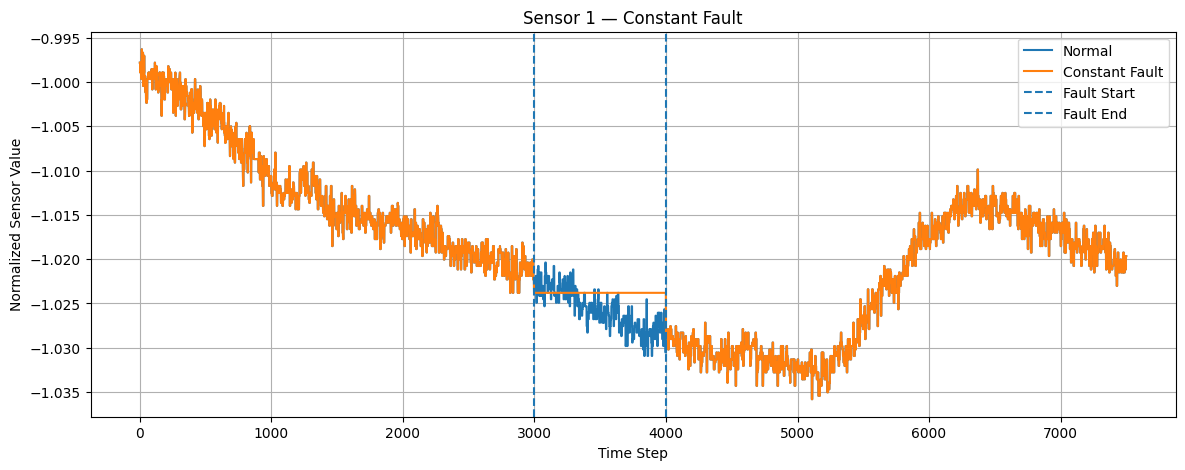

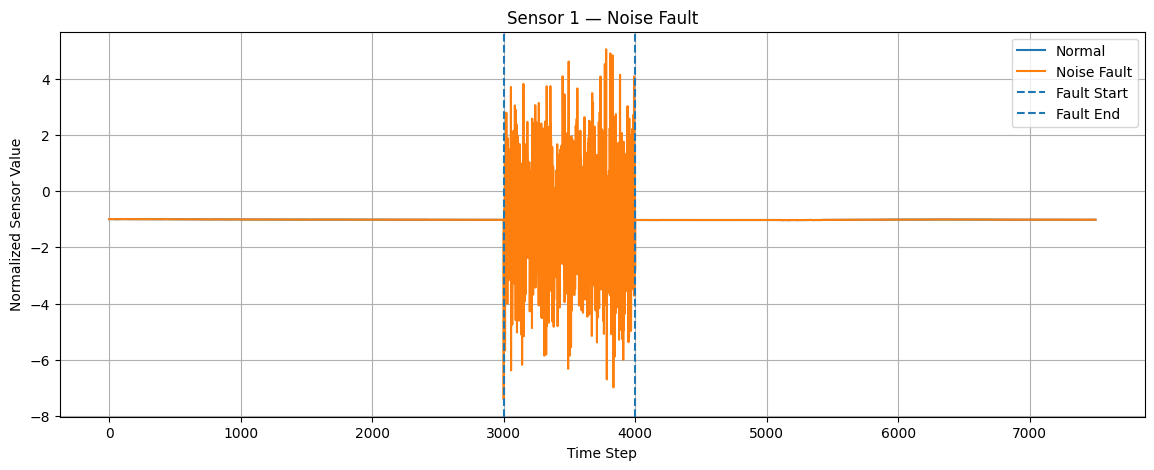

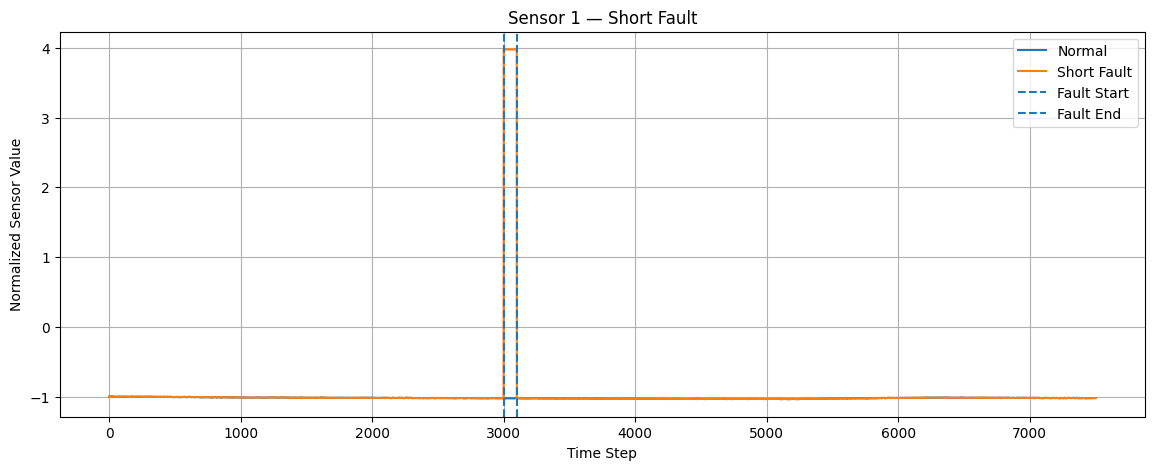

In [27]:
# ============================================================
# VISUALIZE ALL THREE FAULT TYPES
# ============================================================

# Use the same test experiment
normal_signal = X_test[0].copy()

# Create faults
constant_signal = inject_constant_fault(
    normal_signal,
    start=3000,
    duration=1000,
    sensor=0
)

noise_signal = inject_noise_fault(
    normal_signal,
    start=3000,
    duration=1000,
    sensor=0,
    noise_level=2.0
)

short_signal = inject_short_fault(
    normal_signal,
    start=3000,
    duration=100,
    sensor=0
)


# ------------------------------------------------------------
# 1. CONSTANT FAULT
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(normal_signal[:, 0], label="Normal")
plt.plot(constant_signal[:, 0], label="Constant Fault")

plt.axvline(3000, linestyle="--", label="Fault Start")
plt.axvline(4000, linestyle="--", label="Fault End")

plt.title("Sensor 1 — Constant Fault")
plt.xlabel("Time Step")
plt.ylabel("Normalized Sensor Value")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 2. NOISE FAULT
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(normal_signal[:, 0], label="Normal")
plt.plot(noise_signal[:, 0], label="Noise Fault")

plt.axvline(3000, linestyle="--", label="Fault Start")
plt.axvline(4000, linestyle="--", label="Fault End")

plt.title("Sensor 1 — Noise Fault")
plt.xlabel("Time Step")
plt.ylabel("Normalized Sensor Value")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 3. SHORT FAULT
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(normal_signal[:, 0], label="Normal")
plt.plot(short_signal[:, 0], label="Short Fault")

plt.axvline(3000, linestyle="--", label="Fault Start")
plt.axvline(3100, linestyle="--", label="Fault End")

plt.title("Sensor 1 — Short Fault")
plt.xlabel("Time Step")
plt.ylabel("Normalized Sensor Value")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# ============================================================
# CREATE LABELED TIME-SERIES WINDOWS
# ============================================================

WINDOW_SIZE = 250
FAULT_START = 100
FAULT_DURATION = 100

np.random.seed(42)


# ------------------------------------------------------------
# FAULT INJECTION
# ------------------------------------------------------------

def create_faulty_window(normal_window, fault_type, sensor):
    """
    Inject one controlled sensor fault into a time-series window.

    Label:
        0 = normal
        1 = faulty
    """

    faulty = normal_window.copy()

    fault_start = FAULT_START
    fault_end = FAULT_START + FAULT_DURATION

    if fault_type == "constant":

        # Sensor gets stuck at the value at fault onset
        constant_value = faulty[fault_start, sensor]

        faulty[
            fault_start:fault_end,
            sensor
        ] = constant_value

    elif fault_type == "noise":

        # Add abnormal Gaussian noise
        noise = np.random.normal(
            loc=0,
            scale=1.5,
            size=FAULT_DURATION
        )

        faulty[
            fault_start:fault_end,
            sensor
        ] += noise

    elif fault_type == "short":

        # Temporary abnormal deviation
        faulty[
            fault_start:fault_end,
            sensor
        ] += 5.0

    return faulty


# ------------------------------------------------------------
# CREATE WINDOWS
# ------------------------------------------------------------

def create_dataset(experiment_data):
    """
    Convert experiments into normal and faulty
    250-time-step windows.
    """

    X_list = []
    y_list = []
    fault_types = []

    for experiment in experiment_data:

        # 7500 / 250 = 30 windows
        number_of_windows = experiment.shape[0] // WINDOW_SIZE

        for w in range(number_of_windows):

            start = w * WINDOW_SIZE
            end = start + WINDOW_SIZE

            normal_window = experiment[start:end].copy()

            # ----------------------------------------
            # NORMAL SAMPLE
            # ----------------------------------------

            X_list.append(normal_window)
            y_list.append(0)
            fault_types.append("normal")

            # ----------------------------------------
            # RANDOM SENSOR
            # ----------------------------------------

            sensor = np.random.randint(0, 16)

            # ----------------------------------------
            # RANDOM FAULT
            # ----------------------------------------

            fault_type = np.random.choice([
                "constant",
                "noise",
                "short"
            ])

            # ----------------------------------------
            # FAULTY SAMPLE
            # ----------------------------------------

            faulty_window = create_faulty_window(
                normal_window,
                fault_type,
                sensor
            )

            X_list.append(faulty_window)
            y_list.append(1)
            fault_types.append(fault_type)

    return (
        np.array(X_list),
        np.array(y_list),
        np.array(fault_types)
    )


# ============================================================
# CREATE TRAINING DATA
# ============================================================

X_train_seq, y_train, train_fault_types = create_dataset(
    X_train
)


# ============================================================
# CREATE VALIDATION DATA
# ============================================================

X_val_seq, y_val, val_fault_types = create_dataset(
    X_val
)


# ============================================================
# CREATE TEST DATA
# ============================================================

X_test_seq, y_test, test_fault_types = create_dataset(
    X_test
)


# ============================================================
# RESULTS
# ============================================================

print("========================================")
print("SEQUENCE DATASET CREATED")
print("========================================")

print("\nTraining:")
print("X:", X_train_seq.shape)
print("y:", y_train.shape)

print("\nValidation:")
print("X:", X_val_seq.shape)
print("y:", y_val.shape)

print("\nTesting:")
print("X:", X_test_seq.shape)
print("y:", y_test.shape)

print("\nTraining labels:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nTraining fault types:")
print(
    pd.Series(train_fault_types)
    .value_counts()
)

SEQUENCE DATASET CREATED

Training:
X: (2400, 250, 16)
y: (2400,)

Validation:
X: (540, 250, 16)
y: (540,)

Testing:
X: (540, 250, 16)
y: (540,)

Training labels:
0    1200
1    1200
Name: count, dtype: int64

Training fault types:
normal      1200
constant     405
noise        402
short        393
Name: count, dtype: int64


In [30]:
# ============================================================
# INSTALL HMM LIBRARY
# ============================================================

!pip -q install hmmlearn

print("hmmlearn installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.7 MB/s eta 0:00:00
hmmlearn installed successfully!


In [31]:
# ============================================================
# PREPARE DATA FOR ANN
# ============================================================

# Flatten each temporal window
X_train_ann = X_train_seq.reshape(
    X_train_seq.shape[0],
    -1
)

X_val_ann = X_val_seq.reshape(
    X_val_seq.shape[0],
    -1
)

X_test_ann = X_test_seq.reshape(
    X_test_seq.shape[0],
    -1
)

print("ANN input shapes:")
print("Training   :", X_train_ann.shape)
print("Validation :", X_val_ann.shape)
print("Testing    :", X_test_ann.shape)

print("\nEach sample contains:")
print("250 time steps × 16 sensors =", X_train_ann.shape[1], "features")

ANN input shapes:
Training   : (2400, 4000)
Validation : (540, 4000)
Testing    : (540, 4000)

Each sample contains:
250 time steps × 16 sensors = 4000 features


In [32]:
# ============================================================
# TRAIN ANN BASELINE
# ============================================================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import time

# Create ANN
ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=30,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=5,
    verbose=True
)

# Measure training time
start_time = time.perf_counter()

ann_model.fit(
    X_train_ann,
    y_train
)

training_time = time.perf_counter() - start_time

print("\n========================================")
print("ANN TRAINING COMPLETE")
print("========================================")

print("Training time:", round(training_time, 3), "seconds")
print("Iterations:", ann_model.n_iter_)

Iteration 1, loss = 1.10283199
Validation score: 0.613889
Iteration 2, loss = 0.91706663
Validation score: 0.608333
Iteration 3, loss = 0.72731653
Validation score: 0.558333
Iteration 4, loss = 0.78519566
Validation score: 0.636111
Iteration 5, loss = 0.69810309
Validation score: 0.536111
Iteration 6, loss = 0.75831491
Validation score: 0.588889
Iteration 7, loss = 0.71067398
Validation score: 0.636111
Iteration 8, loss = 0.65900416
Validation score: 0.636111
Iteration 9, loss = 0.70707918
Validation score: 0.636111
Iteration 10, loss = 0.70327109
Validation score: 0.636111
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.

ANN TRAINING COMPLETE
Training time: 15.052 seconds
Iterations: 10


In [33]:
# ============================================================
# EVALUATE ANN
# ============================================================

# Predictions
y_val_pred = ann_model.predict(X_val_ann)
y_test_pred = ann_model.predict(X_test_ann)

# Metrics
ann_accuracy = accuracy_score(y_test, y_test_pred)

ann_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

ann_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

ann_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print("========================================")
print("ANN TEST RESULTS")
print("========================================")

print("Accuracy :", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall   :", round(ann_recall, 4))
print("F1 Score :", round(ann_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Normal", "Fault"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

ANN TEST RESULTS
Accuracy : 0.6296
Precision: 0.8302
Recall   : 0.3259
F1 Score : 0.4681

Classification Report:
              precision    recall  f1-score   support

      Normal       0.58      0.93      0.72       270
       Fault       0.83      0.33      0.47       270

    accuracy                           0.63       540
   macro avg       0.71      0.63      0.59       540
weighted avg       0.71      0.63      0.59       540


Confusion Matrix:
[[252  18]
 [182  88]]


In [34]:
# ============================================================
# ANN INFERENCE TIME
# ============================================================

# Warm-up
ann_model.predict(X_test_ann[:10])

start_time = time.perf_counter()

ann_model.predict(X_test_ann)

inference_time = time.perf_counter() - start_time

average_inference_time = (
    inference_time / len(X_test_ann)
)

print("Total inference time:",
      round(inference_time, 6), "seconds")

print("Average inference time per window:",
      round(average_inference_time * 1000, 4),
      "ms")

Total inference time: 0.126118 seconds
Average inference time per window: 0.2336 ms


In [35]:
# ============================================================
# CREATE CHRONOLOGICAL SEQUENCES FOR ANN-HMM
# ============================================================

WINDOW_SIZE = 250
FAULT_START = 3000
FAULT_DURATION = 1000

def create_continuous_fault_experiment(
    experiment,
    fault_type,
    sensor=0
):
    """
    Create one continuous experiment with a single injected fault.

    Returns:
        faulty_experiment
        point-level fault labels
    """

    faulty = experiment.copy()

    labels = np.zeros(
        experiment.shape[0],
        dtype=int
    )

    fault_end = FAULT_START + FAULT_DURATION

    if fault_type == "constant":

        constant_value = faulty[FAULT_START, sensor]

        faulty[
            FAULT_START:fault_end,
            sensor
        ] = constant_value

    elif fault_type == "noise":

        noise = np.random.normal(
            0,
            1.5,
            FAULT_DURATION
        )

        faulty[
            FAULT_START:fault_end,
            sensor
        ] += noise

    elif fault_type == "short":

        # Short fault lasts 100 samples
        short_end = FAULT_START + 100

        faulty[
            FAULT_START:short_end,
            sensor
        ] += 5.0

        fault_end = short_end

    labels[FAULT_START:fault_end] = 1

    return faulty, labels


def create_hmm_sequences(experiment_data):
    """
    Convert each complete experiment into chronological
    250-point windows.

    Each experiment receives ONE injected fault.
    """

    X_list = []
    y_list = []
    experiment_ids = []

    fault_types = [
        "constant",
        "noise",
        "short"
    ]

    for exp_number, experiment in enumerate(experiment_data):

        # Select fault type deterministically
        fault_type = fault_types[
            exp_number % len(fault_types)
        ]

        # Select sensor
        sensor = exp_number % 16

        faulty_experiment, point_labels = (
            create_continuous_fault_experiment(
                experiment,
                fault_type,
                sensor
            )
        )

        # Divide the complete experiment into windows
        number_of_windows = (
            experiment.shape[0] // WINDOW_SIZE
        )

        for w in range(number_of_windows):

            start = w * WINDOW_SIZE
            end = start + WINDOW_SIZE

            X_list.append(
                faulty_experiment[start:end]
            )

            # Window is faulty if ANY point in it is faulty
            window_label = int(
                point_labels[start:end].any()
            )

            y_list.append(window_label)
            experiment_ids.append(exp_number)

    return (
        np.array(X_list),
        np.array(y_list),
        np.array(experiment_ids)
    )


# ============================================================
# CREATE CHRONOLOGICAL TEST DATA
# ============================================================

X_hmm_test, y_hmm_test, hmm_test_exp = (
    create_hmm_sequences(X_test)
)


print("========================================")
print("CHRONOLOGICAL HMM DATA CREATED")
print("========================================")

print("X shape:", X_hmm_test.shape)
print("y shape:", y_hmm_test.shape)

print("\nLabel distribution:")
print(
    pd.Series(y_hmm_test)
    .value_counts()
    .sort_index()
)

print("\nExpected:")
print("9 experiments × 30 windows = 270 windows")

CHRONOLOGICAL HMM DATA CREATED
X shape: (270, 250, 16)
y shape: (270,)

Label distribution:
0    243
1     27
Name: count, dtype: int64

Expected:
9 experiments × 30 windows = 270 windows


In [36]:
# ============================================================
# CREATE CHRONOLOGICAL VALIDATION DATA FOR HMM
# ============================================================

X_hmm_val, y_hmm_val, hmm_val_exp = (
    create_hmm_sequences(X_val)
)

print("Validation HMM data:")
print("X shape:", X_hmm_val.shape)
print("y shape:", y_hmm_val.shape)

print("\nLabel distribution:")
print(
    pd.Series(y_hmm_val)
    .value_counts()
    .sort_index()
)

Validation HMM data:
X shape: (270, 250, 16)
y shape: (270,)

Label distribution:
0    243
1     27
Name: count, dtype: int64


In [37]:
# ============================================================
# ANN PROBABILITIES FOR HMM
# ============================================================

# Flatten chronological windows for ANN
X_hmm_val_ann = X_hmm_val.reshape(
    X_hmm_val.shape[0],
    -1
)

X_hmm_test_ann = X_hmm_test.reshape(
    X_hmm_test.shape[0],
    -1
)

# Get probability of the FAULT class
val_fault_probability = ann_model.predict_proba(
    X_hmm_val_ann
)[:, 1]

test_fault_probability = ann_model.predict_proba(
    X_hmm_test_ann
)[:, 1]

print("Validation probabilities:",
      val_fault_probability.shape)

print("Test probabilities:",
      test_fault_probability.shape)

print("\nFirst 10 validation fault probabilities:")
print(
    np.round(val_fault_probability[:10], 3)
)

Validation probabilities: (270,)
Test probabilities: (270,)

First 10 validation fault probabilities:
[0.492 0.498 0.467 0.511 0.458 0.356 0.195 0.187 0.189 0.182]


In [38]:
# ============================================================
# TRAIN SUPERVISED HMM PARAMETERS
# ============================================================

from hmmlearn.hmm import GaussianHMM

# ------------------------------------------------------------
# Hidden states
# 0 = Normal
# 1 = Fault
# ------------------------------------------------------------

n_states = 2

# ------------------------------------------------------------
# Starting probabilities
# ------------------------------------------------------------

start_counts = np.zeros(n_states)

for exp_id in np.unique(hmm_val_exp):

    labels = y_hmm_val[hmm_val_exp == exp_id]

    start_counts[labels[0]] += 1

startprob = start_counts / start_counts.sum()


# ------------------------------------------------------------
# Transition probabilities
# ------------------------------------------------------------

transition_counts = np.ones(
    (n_states, n_states)
)  # small smoothing value

for exp_id in np.unique(hmm_val_exp):

    labels = y_hmm_val[
        hmm_val_exp == exp_id
    ]

    for i in range(len(labels) - 1):

        current_state = labels[i]
        next_state = labels[i + 1]

        transition_counts[
            current_state,
            next_state
        ] += 1


transmat = (
    transition_counts /
    transition_counts.sum(axis=1, keepdims=True)
)


# ------------------------------------------------------------
# Emission distributions
# ------------------------------------------------------------
# The HMM observes ANN fault probabilities.

means = np.zeros((n_states, 1))
covars = np.zeros((n_states, 1))

for state in range(n_states):

    state_probabilities = (
        val_fault_probability[
            y_hmm_val == state
        ]
    )

    means[state, 0] = state_probabilities.mean()

    # Prevent zero variance
    covars[state, 0] = max(
        state_probabilities.var(),
        1e-4
    )


# ------------------------------------------------------------
# Create HMM
# ------------------------------------------------------------

hmm_model = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    init_params=""
)

hmm_model.startprob_ = startprob
hmm_model.transmat_ = transmat
hmm_model.means_ = means
hmm_model.covars_ = covars


print("========================================")
print("HMM PARAMETERS CREATED")
print("========================================")

print("\nStart probabilities:")
print(np.round(hmm_model.startprob_, 4))

print("\nTransition matrix:")
print(np.round(hmm_model.transmat_, 4))

print("\nEmission means:")
print(np.round(hmm_model.means_, 4))

print("\nEmission variances:")
print(np.round(hmm_model.covars_, 4))

HMM PARAMETERS CREATED

Start probabilities:
[1. 0.]

Transition matrix:
[[0.9576 0.0424]
 [0.3448 0.6552]]

Emission means:
[[0.3905]
 [0.2896]]

Emission variances:


AttributeError: 'GaussianHMM' object has no attribute 'n_features'

In [39]:
# ============================================================
# FIX HMM FEATURE DIMENSION
# ============================================================

# Our HMM observes one feature:
# the ANN's fault probability

hmm_model.n_features = 1

print("HMM feature dimension:", hmm_model.n_features)

print("\nStart probabilities:")
print(np.round(hmm_model.startprob_, 4))

print("\nTransition matrix:")
print(np.round(hmm_model.transmat_, 4))

print("\nEmission means:")
print(np.round(hmm_model.means_, 4))

print("\nEmission variances:")
print(np.round(hmm_model.covars_, 4))

print("\n✓ HMM model is ready!")

HMM feature dimension: 1

Start probabilities:
[1. 0.]

Transition matrix:
[[0.9576 0.0424]
 [0.3448 0.6552]]

Emission means:
[[0.3905]
 [0.2896]]

Emission variances:
[[[0.0212]]

 [[0.0273]]]

✓ HMM model is ready!


In [40]:
test_emissions = test_fault_probability.reshape(-1, 1)

hmm_predictions = []

for exp_id in np.unique(hmm_test_exp):

    sequence = test_emissions[
        hmm_test_exp == exp_id
    ]

    states = hmm_model.predict(sequence)

    hmm_predictions.extend(states)

hmm_predictions = np.array(hmm_predictions)

print("HMM predictions:", hmm_predictions.shape)

print("\nFirst 30 predictions:")
print(hmm_predictions[:30])

print("\nActual labels:")
print(y_hmm_test[:30])

HMM predictions: (270,)

First 30 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Actual labels:
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [41]:
# ============================================================
# ANN-HMM PERFORMANCE
# ============================================================

ann_hmm_accuracy = accuracy_score(
    y_hmm_test,
    hmm_predictions
)

ann_hmm_precision = precision_score(
    y_hmm_test,
    hmm_predictions,
    zero_division=0
)

ann_hmm_recall = recall_score(
    y_hmm_test,
    hmm_predictions,
    zero_division=0
)

ann_hmm_f1 = f1_score(
    y_hmm_test,
    hmm_predictions,
    zero_division=0
)

print("========================================")
print("ANN-HMM TEST RESULTS")
print("========================================")

print("Accuracy :", round(ann_hmm_accuracy, 4))
print("Precision:", round(ann_hmm_precision, 4))
print("Recall   :", round(ann_hmm_recall, 4))
print("F1 Score :", round(ann_hmm_f1, 4))

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_hmm_test,
        hmm_predictions
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_hmm_test,
        hmm_predictions,
        target_names=["Normal", "Fault"],
        zero_division=0
    )
)

ANN-HMM TEST RESULTS
Accuracy : 0.7926
Precision: 0.1778
Recall   : 0.2963
F1 Score : 0.2222

Confusion Matrix:
[[206  37]
 [ 19   8]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.85      0.88       243
       Fault       0.18      0.30      0.22        27

    accuracy                           0.79       270
   macro avg       0.55      0.57      0.55       270
weighted avg       0.84      0.79      0.81       270



In [42]:
# ============================================================
# FAULT DETECTION DELAY
# ============================================================

SAMPLE_RATE = 25
WINDOW_DURATION_SECONDS = WINDOW_SIZE / SAMPLE_RATE

detection_delays = []

for exp_id in np.unique(hmm_test_exp):

    mask = hmm_test_exp == exp_id

    actual = y_hmm_test[mask]
    predicted = hmm_predictions[mask]

    # First actual fault window
    actual_fault_indices = np.where(actual == 1)[0]

    # First detected fault window
    detected_fault_indices = np.where(predicted == 1)[0]

    if len(actual_fault_indices) == 0:
        continue

    actual_start = actual_fault_indices[0]

    if len(detected_fault_indices) == 0:

        delay = np.nan

    else:

        detected_start = detected_fault_indices[0]

        delay_windows = max(
            0,
            detected_start - actual_start
        )

        delay = (
            delay_windows *
            WINDOW_DURATION_SECONDS
        )

    detection_delays.append(delay)


detection_delays = np.array(
    detection_delays,
    dtype=float
)

valid_delays = detection_delays[
    ~np.isnan(detection_delays)
]


print("========================================")
print("FAULT DETECTION DELAY")
print("========================================")

print(
    "Window duration:",
    WINDOW_DURATION_SECONDS,
    "seconds"
)

print(
    "Experiments with detection:",
    len(valid_delays)
)

if len(valid_delays) > 0:

    print(
        "Average detection delay:",
        round(valid_delays.mean(), 3),
        "seconds"
    )

    print(
        "Median detection delay:",
        round(np.median(valid_delays), 3),
        "seconds"
    )

    print(
        "Maximum detection delay:",
        round(valid_delays.max(), 3),
        "seconds"
    )
else:

    print("No faults were detected.")

FAULT DETECTION DELAY
Window duration: 10.0 seconds
Experiments with detection: 2
Average detection delay: 0.0 seconds
Median detection delay: 0.0 seconds
Maximum detection delay: 0.0 seconds


In [43]:
# ============================================================
# SAVE ANN-HMM BASELINE RESULTS
# ============================================================

ann_hmm_results = {
    "Model": "ANN-HMM",
    "Accuracy": ann_hmm_accuracy,
    "Precision": ann_hmm_precision,
    "Recall": ann_hmm_recall,
    "F1": ann_hmm_f1,
    "Average Detection Delay (s)": (
        valid_delays.mean()
        if len(valid_delays) > 0
        else np.nan
    )
}

print(ann_hmm_results)

{'Model': 'ANN-HMM', 'Accuracy': 0.7925925925925926, 'Precision': 0.17777777777777778, 'Recall': 0.2962962962962963, 'F1': 0.2222222222222222, 'Average Detection Delay (s)': np.float64(0.0)}


In [44]:
# ============================================================
# ANN-HMM BASELINE AUDIT
# ============================================================

print("========================================")
print("ANN-HMM BASELINE AUDIT")
print("========================================")

print("\nAccuracy :", round(ann_hmm_accuracy, 4))
print("Precision:", round(ann_hmm_precision, 4))
print("Recall   :", round(ann_hmm_recall, 4))
print("F1 Score :", round(ann_hmm_f1, 4))

print("\nConfusion Matrix:")
cm = confusion_matrix(
    y_hmm_test,
    hmm_predictions
)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nActual fault windows:",
      np.sum(y_hmm_test == 1))

print("Detected fault windows:",
      np.sum(hmm_predictions == 1))

print("\nFault detection rate:",
      round(
          np.sum(
              (y_hmm_test == 1) &
              (hmm_predictions == 1)
          )
          / np.sum(y_hmm_test == 1),
          4
      ))

ANN-HMM BASELINE AUDIT

Accuracy : 0.7926
Precision: 0.1778
Recall   : 0.2963
F1 Score : 0.2222

Confusion Matrix:
[[206  37]
 [ 19   8]]

True Negatives : 206
False Positives: 37
False Negatives: 19
True Positives : 8

Actual fault windows: 27
Detected fault windows: 45

Fault detection rate: 0.2963


In [45]:
# ============================================================
# COMPARE ANN VS ANN-HMM
# ============================================================

ann_hmm_test_results = pd.DataFrame({
    "Actual": y_hmm_test,
    "ANN_Probability": test_fault_probability,
    "ANN_Prediction": (
        test_fault_probability >= 0.5
    ).astype(int),
    "HMM_Prediction": hmm_predictions,
    "Experiment": hmm_test_exp
})

print("ANN vs HMM predictions:")
display(
    ann_hmm_test_results.head(30)
)

print("\nANN prediction distribution:")
print(
    ann_hmm_test_results["ANN_Prediction"]
    .value_counts()
)

print("\nHMM prediction distribution:")
print(
    ann_hmm_test_results["HMM_Prediction"]
    .value_counts()
)

ANN vs HMM predictions:


,Actual,ANN_Probability,ANN_Prediction,HMM_Prediction,Experiment
0,0,0.492006,0,0,0
1,0,0.487421,0,0,0
2,0,0.493952,0,0,0
3,0,0.496861,0,0,0
4,0,0.492773,0,0,0
5,0,0.488187,0,0,0
6,0,0.496718,0,0,0
7,0,0.496985,0,0,0
8,0,0.491729,0,0,0
9,0,0.489303,0,0,0



ANN prediction distribution:
ANN_Prediction
0    248
1     22
Name: count, dtype: int64

HMM prediction distribution:
HMM_Prediction
0    225
1     45
Name: count, dtype: int64
